In [28]:
# Install Required Libraries

!pip install yfinance
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install ta
!pip install plotly
!pip install jupyter


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip insta

In [29]:
import yfinance as yf

df = yf.download(
    "SPY",
    start="2010-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Flatten MultiIndex columns if present
if hasattr(df.columns, "nlevels") and df.columns.nlevels > 1:
    df.columns = df.columns.get_level_values(0)

df.reset_index(inplace=True)

df.to_csv("spy_data.csv", index=False)

print(df.head())
print(df.columns)

[*********************100%***********************]  1 of 1 completed

Price       Date      Close       High        Low       Open     Volume
0     2010-01-04  84.578461  84.623237  83.220190  83.862011  118944600
1     2010-01-05  84.802353  84.839670  84.220238  84.526225  111579900
2     2010-01-06  84.862068  85.071032  84.653104  84.720269  116074400
3     2010-01-07  85.220306  85.324788  84.466539  84.705356  131091100
4     2010-01-08  85.503883  85.541201  84.824751  84.996397  126402800
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [30]:
#Basic Information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    3774 non-null   datetime64[s]
 1   Close   3774 non-null   float64      
 2   High    3774 non-null   float64      
 3   Low     3774 non-null   float64      
 4   Open    3774 non-null   float64      
 5   Volume  3774 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1)
memory usage: 177.0 KB


In [31]:
df.describe()

Price,Date,Close,High,Low,Open,Volume
count,3774,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,2017-07-01 21:42:38,244.511791,245.782106,243.045569,244.472473,1.118054e+08
min,2010-01-04 00:00:00,76.950607,77.869197,76.144978,77.635787,2.027000e+07
25%,2013-10-02 06:00:00,136.859970,137.220888,136.351668,136.692987,6.614835e+07
50%,2017-07-01 12:00:00,211.043816,211.684369,210.298160,211.113131,9.190805e+07
75%,2021-03-31 18:00:00,358.334793,361.075994,354.498853,357.712806,1.360184e+08
max,2024-12-31 00:00:00,595.575073,596.809720,594.800997,595.457415,7.178287e+08
std,NaN,130.818386,131.486198,130.058442,130.810160,6.908714e+07


In [32]:
df.isnull().sum()

Price
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

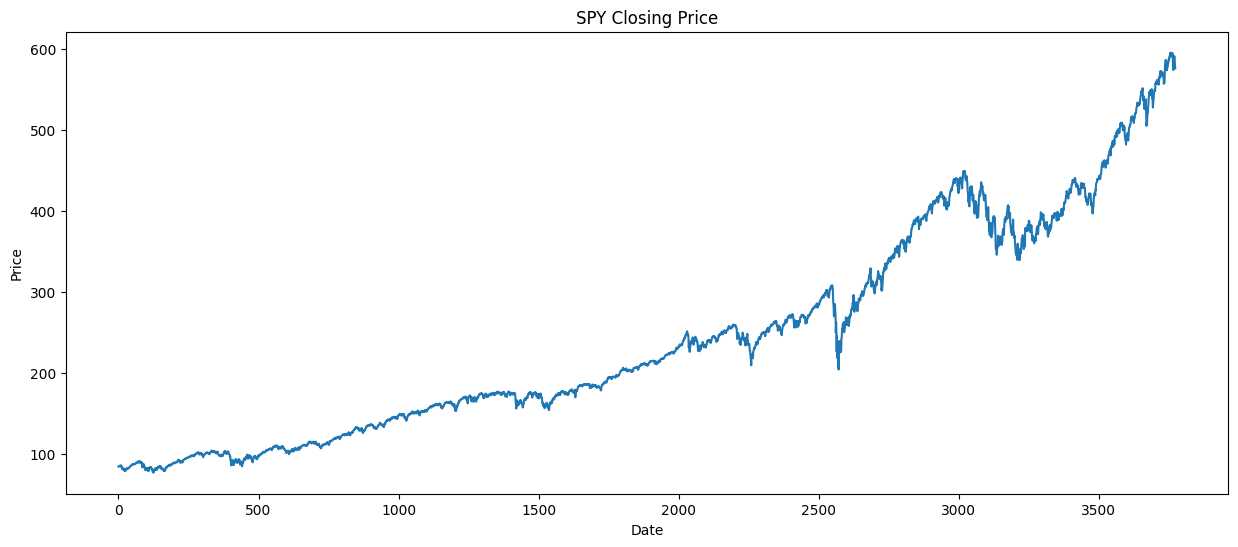

In [33]:
#Plotting the Closing Price of SPY
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(df["Close"])
plt.title("SPY Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

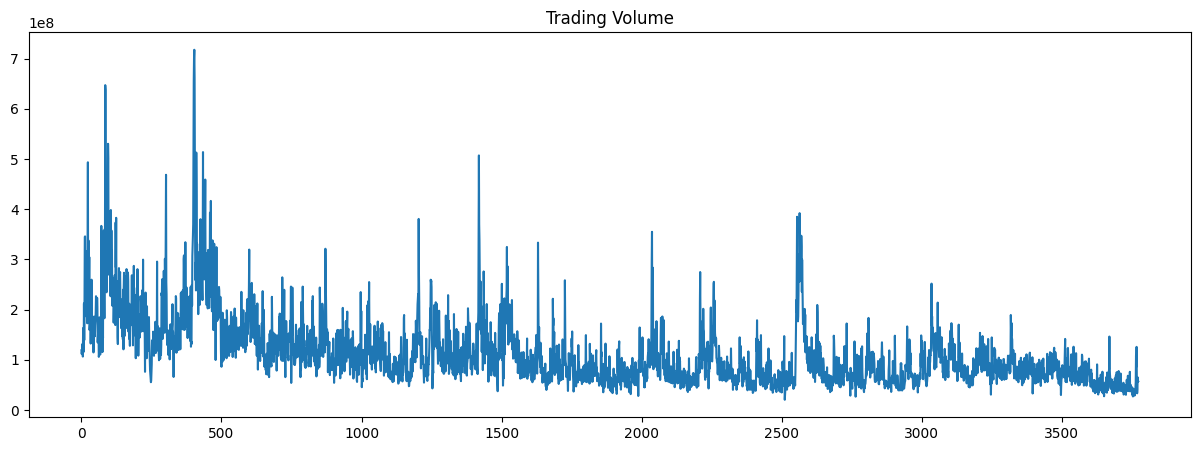

In [34]:
#Plotting the Trading Volume of SPY
plt.figure(figsize=(15,5))
plt.plot(df["Volume"])
plt.title("Trading Volume")
plt.show()

In [35]:
#Daily Returns of SPY
df["Returns"] = df["Close"].pct_change()

In [36]:
df["Returns"].describe()

count    3773.000000
mean        0.000567
std         0.010741
min        -0.109424
25%        -0.003709
50%         0.000682
75%         0.005790
max         0.090603
Name: Returns, dtype: float64

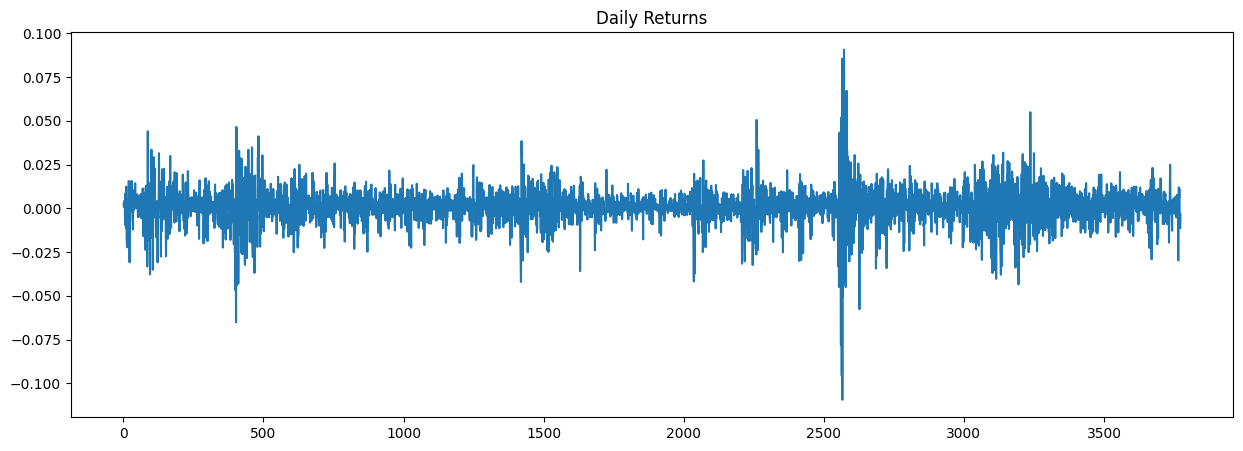

In [37]:
plt.figure(figsize=(15,5))
plt.plot(df["Returns"])
plt.title("Daily Returns")
plt.show()

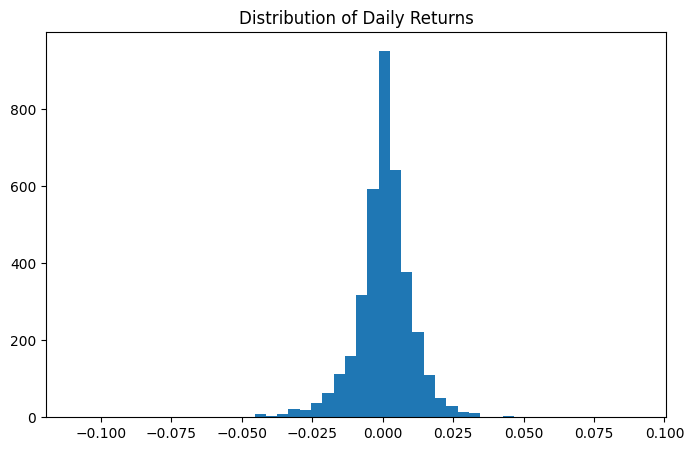

In [38]:
#Histogram of Daily Returns
plt.figure(figsize=(8,5))
plt.hist(df["Returns"].dropna(), bins=50)
plt.title("Distribution of Daily Returns")
plt.show()

In [39]:
#Rolling Statistics
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()

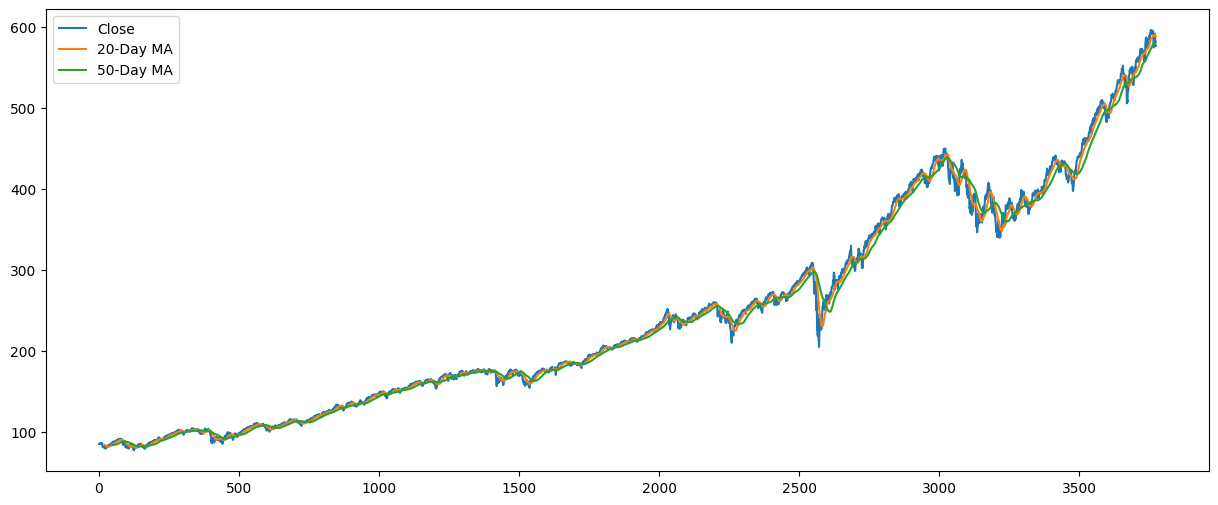

In [40]:
plt.figure(figsize=(15,6))

plt.plot(df["Close"], label="Close")
plt.plot(df["MA20"], label="20-Day MA")
plt.plot(df["MA50"], label="50-Day MA")

plt.legend()
plt.show()

In [41]:
#Volatility
df["Volatility"] = df["Returns"].rolling(20).std()

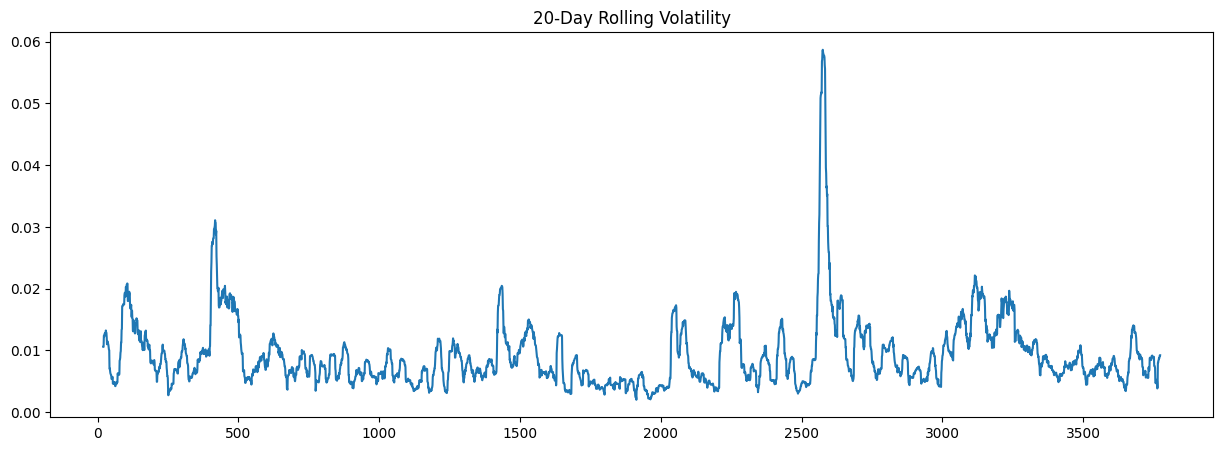

In [42]:
plt.figure(figsize=(15,5))
plt.plot(df["Volatility"])
plt.title("20-Day Rolling Volatility")
plt.show()

In [43]:
df.to_csv("../data/spy_data.csv")
print(df.head())

Price       Date      Close       High        Low       Open     Volume  \
0     2010-01-04  84.578461  84.623237  83.220190  83.862011  118944600   
1     2010-01-05  84.802353  84.839670  84.220238  84.526225  111579900   
2     2010-01-06  84.862068  85.071032  84.653104  84.720269  116074400   
3     2010-01-07  85.220306  85.324788  84.466539  84.705356  131091100   
4     2010-01-08  85.503883  85.541201  84.824751  84.996397  126402800   

Price   Returns  MA20  MA50  Volatility  
0           NaN   NaN   NaN         NaN  
1      0.002647   NaN   NaN         NaN  
2      0.000704   NaN   NaN         NaN  
3      0.004221   NaN   NaN         NaN  
4      0.003328   NaN   NaN         NaN  
